# С кем ходит тенге?

Разведка данных по официальным курсам Национального Банка РК.

Вопрос, с которого всё началось. В Казахстане про курс тенге говорят двумя
способами сразу: «тенге идёт за рублём» и «тенге идёт за нефтью». Оба
утверждения звучат уверенно, но ни одно обычно не подкрепляется цифрой.
Здесь я беру открытые данные Нацбанка и смотрю, что из этого видно в самих
курсах: с какой из 47 котируемых валют тенге действительно двигается
в одну ногу, насколько сильно и всегда ли.

Ноутбук — это разведка. Финальные цифры и выводы собраны в
[reports/findings.md](../reports/findings.md), воспроизводимый прогон — в `src/pipeline.py`.

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import analysis as A
from src import clean, features

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (11, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Что вообще пришло из источника

Эндпоинт Нацбанка отдаёт по одному дню за запрос. Загрузчик (`src/fetch_nbk.py`)
прошёл по всем датам с мая 2021 года и сложил ответы в один CSV.

In [2]:
raw = clean.load_raw()
raw.head()

Прочитал 75561 строк из nbk_rates_raw.csv


,date,code,name_ru,quant,value,change
0,2021-05-07,AUD,АВСТРАЛИЙСКИЙ ДОЛЛАР,1,329.6,-1.36
1,2021-05-07,AZN,АЗЕРБАЙДЖАНСКИЙ МАНАТ,1,269.55,+17.34
2,2021-05-07,AMD,АРМЯНСКИЙ ДРАМ,10,12.66,+4.45
3,2021-05-07,BYN,БЕЛОРУССКИЙ РУБЛЬ,1,149.48,-18.51
4,2021-05-07,BRL,БРАЗИЛЬСКИЙ РЕАЛ,1,89.76,+10.00


In [3]:
long = clean.tidy(raw)
wide = clean.to_wide(long)
print("дней в выборке:", len(wide))
print("валют:", wide.shape[1])
print("период:", wide.index.min().date(), "->", wide.index.max().date())

дней в выборке: 1922
валют: 48
период: 2021-05-07 -> 2026-09-11


## 2. Три ловушки в данных

### 2.1. Курс публикуется не за одну единицу

Драм котируется за 10 штук, узбекский сум — за 100, вьетнамский донг — за 1000.
Если этого не заметить, «узбекский сум» окажется дороже евро.

In [4]:
sample = raw[raw.date == raw.date.max()][["code", "quant", "value"]]
sample[sample["quant"] != "1"].head(8)

,code,quant,value
75515,AMD,10,12.45
75518,HUF,10,14.41
75519,VND,1000,17.39
75529,IDR,1000,25.72
75530,IRR,10000,3.28
75539,MNT,100,12.54
75552,UZS,100,3.83
75559,KRW,100,33.58


### 2.2. Половина дней — не торговые

В выходные и праздники Нацбанк не устанавливает новый курс, а повторяет
предыдущий. Ловим такие дни не по календарю праздников (они в РК плавают),
а по признаку: изменение ровно ноль сразу по всем валютам.

In [5]:
changed = wide.diff().abs().sum(axis=1)
print("дней без единого изменения:", int(changed.eq(0).sum()), "из", len(wide))

wide_t, dropped = clean.drop_non_trading_days(wide)
wide_t = clean.drop_snapshot_echoes(wide_t)
print("осталось торговых дней:", len(wide_t))

дней без единого изменения: 627 из 1922
  убираю 626 дней без изменения курсов (выходные/праздники)
  убираю 1 строк-заглушек: ['2021-05-07']
осталось торговых дней: 1295


### 2.3. На даты вне архива сервис отдаёт не ошибку, а сегодняшний снимок

Это самая неприятная ловушка: строка выглядит абсолютно нормально.
Поймать её можно только по тому, что она совпадает с одним из последних дней
выборки до шестого знака сразу по десяткам валют.

In [6]:
echo = wide.loc["2021-05-07"]
last = wide.iloc[-1]
common = echo.dropna().index.intersection(last.dropna().index)
print("совпадений с последним днём выборки:", int((echo[common] == last[common]).sum()), "из", len(common))
pd.DataFrame({"2021-05-07": echo[["USD", "EUR", "RUB", "CNY"]], "последний день": last[["USD", "EUR", "RUB", "CNY"]]})

совпадений с последним днём выборки: 0 из 48


,2021-05-07,последний день
USD,456.89,450.79
EUR,531.36,524.13
RUB,5.32,5.31
CNY,68.11,67.22


## 3. Неожиданная находка: дата курса — это не дата торгов

Я собирался посмотреть, есть ли у тенге «день недели», и наткнулся вот на что.

In [7]:
names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
counts = pd.Series(wide_t.index.dayofweek).value_counts().sort_index()
counts.index = [names[i] for i in counts.index]
counts.rename("дней, когда курс изменился")

Пн      1
Вт    247
Ср    257
Чт    260
Пт    264
Сб    260
Вс      6
Name: дней, когда курс изменился, dtype: int64

Понедельник — один-единственный день за пять лет, зато суббота полноценная.
Объяснение простое: курс, объявленный на дату D, посчитан по торгам дня D-1.
Курс «на субботу» — это результат пятничных торгов, а «на понедельник»
просто повторяет его.

Для корреляций это ничего не меняет (сдвинуты одинаково все валюты),
но любые календарные выводы без поправки считались бы не по тем дням.

In [8]:
prices = features.to_usd_base(wide_t)
rets = features.log_returns(prices)
rets_trade = features.to_trading_date(rets)

counts = pd.Series(rets_trade.index.dayofweek).value_counts().sort_index()
counts.index = [names[i] for i in counts.index]
counts.rename("после сдвига на день назад")

  обнуляю доходность через разрывы календаря: ['2022-01-13', '2022-03-25', '2023-08-22', '2023-08-29', '2024-03-27', '2025-03-27', '2026-03-27']


Пн    247
Вт    257
Ср    260
Чт    264
Пт    259
Сб      6
Вс      1
Name: после сдвига на день назад, dtype: int64

## 4. Приводим всё к одной базе

Нацбанк котирует всё в тенге. Сравнивать такие ряды между собой нельзя:
в каждом уже сидит сам тенге, и любые две пары будут коррелировать просто
из-за общего знаменателя. Пересчитываем в доллары:

$$X \text{ за } 1\,USD = \frac{KZT \text{ за } 1\,USD}{KZT \text{ за } 1\,X}$$

Знак доходности: плюс = валюта ослабла к доллару.

In [9]:
prices[["KZT", "RUB", "CNY", "TRY"]].tail(3).round(3)

,KZT,RUB,CNY,TRY
date,,,,
2026-09-09,454.46,86.564,6.711,48.450
2026-09-10,456.89,85.882,6.708,48.451
2026-09-11,450.79,84.895,6.706,48.472


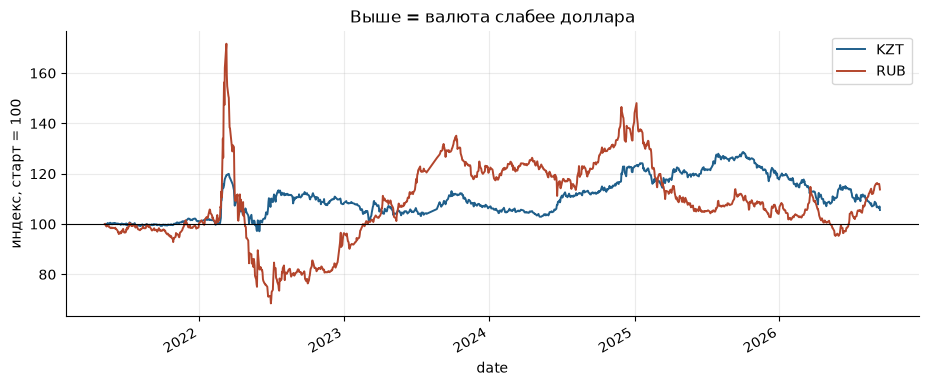

In [10]:
ax = (100 * prices[["KZT", "RUB"]] / prices[["KZT", "RUB"]].iloc[0]).plot(
    color=["#1f5f8b", "#b3452c"], lw=1.4)
ax.axhline(100, color="black", lw=0.8)
ax.set_ylabel("индекс, старт = 100")
ax.set_title("Выше = валюта слабее доллара")
plt.show()

Уже здесь видно кое-что неожиданное. За пять с лишним лет тенге ослаб к доллару
всего на несколько процентов — при всей репутации вечно падающей валюты.
А траектории тенге и рубля в 2022-2023 годах откровенно расходятся.

## 5. Главный вопрос: с кем ходит тенге

Считаем корреляцию дневных доходностей тенге с каждой из валют.

In [11]:
peers = [c for c in rets.columns if c != "KZT"]
corr = A.corr_with(rets, "KZT", peers)
corr.round(3)

RUB    0.320
NOK    0.152
CAD    0.145
EUR    0.135
AUD    0.133
GEL    0.132
INR    0.120
GBP    0.109
MXN    0.100
ZAR    0.090
CNY    0.085
BRL    0.081
CHF    0.055
KGS    0.049
AMD    0.048
JPY    0.042
TRY    0.042
UZS    0.038
BYN    0.006
AZN   -0.010
Name: KZT, dtype: float64

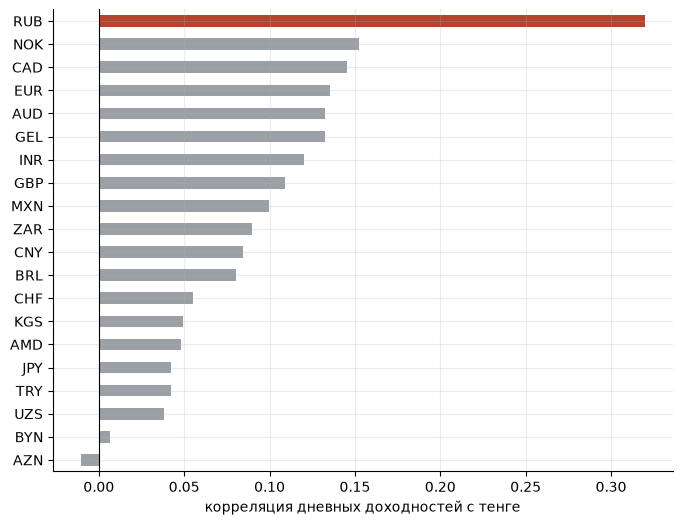

In [12]:
data = corr.sort_values()
colors = ["#b3452c" if c == "RUB" else "#9aa0a6" for c in data.index]
ax = data.plot.barh(color=colors, figsize=(8, 6))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("корреляция дневных доходностей с тенге")
plt.show()

Рубль — 0,32, следующий за ним норвежская крона — 0,15. Отрыв двукратный.

Дальше сразу два наблюдения, которые стоит проверить:

- за рублём идут NOK и CAD — нефтяные валюты. Это косвенно поддерживает
  «нефтяную» версию;
- юань, валюта крупнейшего торгового партнёра Казахстана, — почти в конце
  списка. Торговый оборот и валютная связь — это разные вещи.

### А не сдвинут ли один ряд относительно другого?

Официальный курс считается по вчерашним торгам, кросс-курсы берутся с мирового
рынка — сдвиг на день был бы вполне ожидаем. Проверяем.

In [13]:
A.lead_lag_profile(rets, "KZT", "RUB", max_lag=5).round(3)

,lag,corr,n
0,-5,0.052,1275
1,-4,0.004,1276
2,-3,-0.006,1277
3,-2,0.104,1278
4,-1,0.007,1280
5,0,0.320,1287
6,1,0.103,1280
7,2,-0.086,1278
8,3,-0.014,1277
9,4,0.135,1276


Максимум ровно на нуле, соседние лаги втрое меньше. Сдвига нет — обе котировки
берутся из одного дня. Связь одновременная, а не «тенге догоняет рубль завтра».

## 6. Сколько это в объяснённой дисперсии

Корреляция 0,32 звучит внушительно, пока не возвести её в квадрат.

In [14]:
steps = A.stepwise_r2(rets, "KZT", ["RUB", "NOK", "EUR", "CNY", "CAD", "GEL", "INR", "ZAR"])
steps.round(4)

,добавили,r2,прирост_r2
0,RUB,0.1022,0.1022
1,NOK,0.1153,0.0132
2,GEL,0.1227,0.0074
3,INR,0.1254,0.0027
4,ZAR,0.1265,0.0011
5,CAD,0.1274,0.0009
6,EUR,0.1275,0.0001
7,CNY,0.1275,0.0000


In [15]:
one = A.explained_variance(rets, "KZT", ["RUB"])
print(f"рубль в одиночку объясняет {one['r2']:.1%} дневной дисперсии тенге")
print(f"бета к рублю: {one['betas']['RUB']:.3f} — рубль падает на 10%, тенге на {one['betas']['RUB']*10:.1f}%")
print(f"все восемь валют вместе: {steps['r2'].iloc[-1]:.1%}")

рубль в одиночку объясняет 10.2% дневной дисперсии тенге
бета к рублю: 0.137 — рубль падает на 10%, тенге на 1.4%
все восемь валют вместе: 12.7%


То есть 87% дневных движений тенге не объясняются вообще ничем из мировых валют.
Это внутренняя история: интервенции Нацбанка, продажи валюты из Нацфонда,
налоговые периоды, спрос конкретных импортёров.

## 7. Связь включается только в шторм

Средняя корреляция — плохая характеристика, если связь непостоянна.
Смотрим её отдельно по величине движения рубля.

In [16]:
pair = rets[["KZT", "RUB"]].dropna()
rows = []
for lo, hi, label in [(0, .005, "< 0,5%"), (.005, .01, "0,5-1%"), (.01, .02, "1-2%"), (.02, 1, "> 2%")]:
    sub = pair[pair["RUB"].abs().between(lo, hi, inclusive="left")]
    rows.append({"движение рубля": label, "дней": len(sub), "корреляция": round(sub["KZT"].corr(sub["RUB"]), 3)})
pd.DataFrame(rows)

,движение рубля,дней,корреляция
0,"< 0,5%",683,0.060
1,"0,5-1%",306,0.112
2,1-2%,195,0.188
3,> 2%,103,0.549


Вот это и есть настоящий ответ. В спокойные дни — а это больше половины выборки —
корреляция 0,06, то есть её нет. Когда рубль двигается сильнее 2% за день,
корреляция подскакивает до 0,55.

Тенге не «привязан» к рублю. Он его игнорирует, пока не начинается шторм.

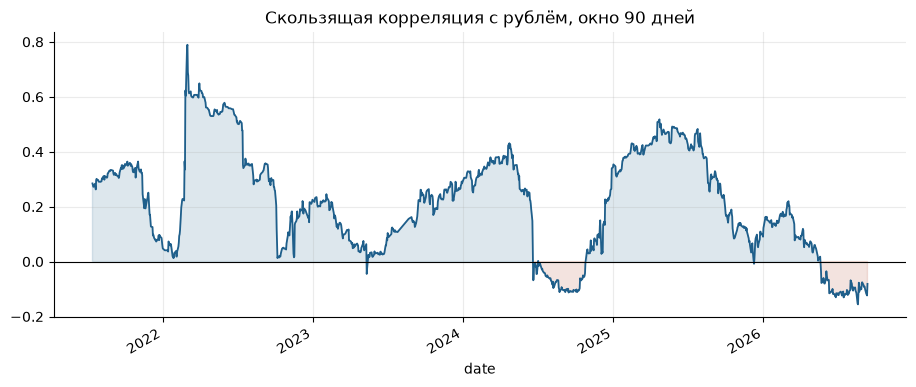

In [17]:
rc = rets["KZT"].rolling(90, min_periods=45).corr(rets["RUB"])
ax = rc.plot(color="#1f5f8b", lw=1.3)
ax.axhline(0, color="black", lw=0.8)
ax.fill_between(rc.index, 0, rc, where=rc > 0, color="#1f5f8b", alpha=.15)
ax.fill_between(rc.index, 0, rc, where=rc < 0, color="#b3452c", alpha=.15)
ax.set_title("Скользящая корреляция с рублём, окно 90 дней")
plt.show()

In [18]:
A.corr_by_year(rets, "KZT", ["RUB", "NOK", "EUR", "CNY", "UZS", "GEL"]).round(3)

,2021,2022,2023,2024,2025,2026
CNY,0.091,0.104,0.024,0.151,0.138,-0.049
EUR,0.179,0.199,0.115,0.115,0.134,-0.047
GEL,-0.056,0.244,0.081,0.114,-0.121,-0.056
NOK,0.405,0.210,0.099,0.032,0.228,0.012
RUB,0.180,0.440,0.120,0.190,0.314,-0.024
UZS,-0.067,-0.015,-0.013,0.085,0.152,-0.015


2026 год выбивается из всего ряда: связь с рублём впервые уходит в ноль
и даже слегка в минус. Выборка неполная (январь-сентябрь), так что это скорее
повод следить дальше, чем готовый вывод.

## 8. Вверх по лестнице, вниз на лифте

Второй вопрос: одинаково ли тенге слабеет и крепнет.

In [19]:
A.asymmetry_stats(rets, ["KZT", "RUB", "CNY", "EUR", "UZS", "NOK"])

,дней_ослабления_%,средн_ослабление_%,средн_укрепление_%,отношение_силы,асимметрия,худший_день_%,лучший_день_%
KZT,49.417,0.440,0.425,1.035,1.335,6.373,3.021
RUB,50.427,0.838,0.824,1.017,2.278,19.207,9.189
CNY,50.816,0.155,0.160,0.974,-0.616,1.074,1.653
EUR,51.360,0.329,0.346,0.950,-0.421,1.869,3.026
UZS,50.194,0.246,0.239,1.026,1.200,4.039,1.456
NOK,49.340,0.559,0.533,1.050,0.015,3.571,4.056


Доля дней ослабления — 49,4%, то есть тенге чаще крепнет, чем слабеет.
И при этом асимметрия +1,34, худший день +6,4% против лучшего -3,0%.
Средние по дням почти симметричны, вся разница сидит в хвосте.

Проверим это прямо: что останется от пятилетнего ослабления, если убрать
десяток худших дней.

In [20]:
kzt = rets["KZT"].dropna()
worst = kzt.nlargest(10)
print(f"всего дней: {len(kzt)}")
print(f"итог за период:        {kzt.sum()*100:+.1f}%")
print(f"вклад 10 худших дней:  {worst.sum()*100:+.1f}%")
print(f"итог без этих 10 дней: {kzt.drop(worst.index).sum()*100:+.1f}%")
worst.mul(100).round(2).rename("изменение, %").to_frame()

всего дней: 1287
итог за период:        +3.1%
вклад 10 худших дней:  +33.4%
итог без этих 10 дней: -30.2%


,"изменение, %"
date,
2022-02-25,6.37
2022-03-01,5.80
2026-04-09,3.19
2025-04-08,2.73
2024-11-29,2.66
2022-05-28,2.64
2026-07-14,2.63
2024-12-03,2.58
2022-06-02,2.37


0,8% дней дают ослабление в десять раз больше итогового. В остальное время
тенге медленно крепнет. Это и есть «вверх по лестнице, вниз на лифте» —
только лестница ведёт вверх для тенге, а лифт срабатывает в дни шоков.

И все десять худших дней — это события: февраль-март 2022, ноябрь-декабрь 2024,
весна 2026.

## 9. Проверка народной приметы про налоговую неделю

Считается, что 20-25 числа экспортёры продают валютную выручку под налоги,
и тенге в эти дни крепче. Считаем на торговых датах (с поправкой из раздела 3)
и проверяем перестановочным тестом.

In [21]:
mask = pd.Series(rets_trade.index.day, index=rets_trade.index).between(20, 25)
res = A.permutation_test(rets_trade["KZT"], mask, n_iter=20000)
for k, v in res.items():
    print(f"{k:15s} {v}")

observed_diff   -9.129077152516547e-07
group_mean      2.371877352256391e-05
rest_mean       2.4631681237815564e-05
n_group         250
n_rest          1037
p_value         0.99885


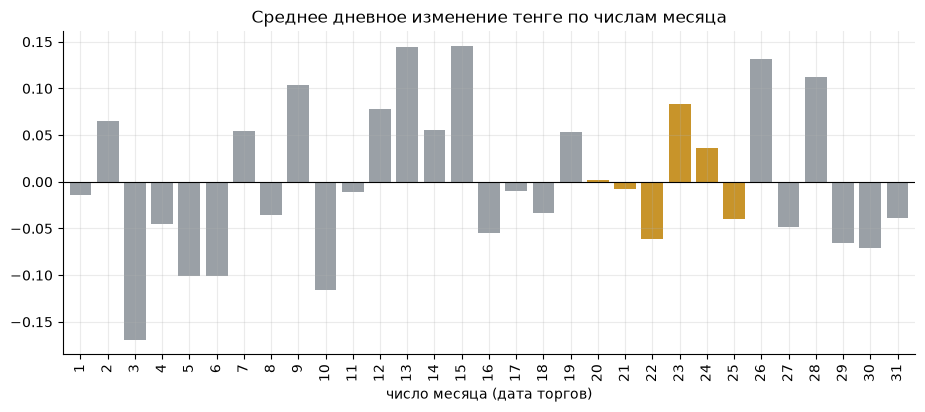

In [22]:
profile = A.intramonth_profile(rets_trade["KZT"])
colors = ["#c8942a" if 20 <= d <= 25 else "#9aa0a6" for d in profile.index]
ax = profile["средн_%"].plot.bar(color=colors, width=.8)
ax.axhline(0, color="black", lw=.8)
ax.set_title("Среднее дневное изменение тенге по числам месяца")
ax.set_xlabel("число месяца (дата торгов)")
plt.show()

p-value 0,99. Разница между налоговой неделей и остальными днями неотличима
от нуля. Примета не подтверждается — по крайней мере на официальном курсе
и на этом периоде.

## Что получилось

1. Ближайший попутчик тенге — рубль, но корреляция всего 0,32, и это ~10%
   объяснённой дисперсии. Оставшиеся 87% (даже с учётом всех валют сразу) —
   не про мировые рынки.
2. Связь с рублём не постоянная, а хвостовая: 0,06 в спокойные дни и 0,55
   в дни, когда рубль ходит больше чем на 2%.
3. Юань, при всём весе Китая в торговле, с тенге почти не связан.
4. Тенге чаще крепнет, чем слабеет, но десять худших дней из 1287 перевешивают
   все остальные пять лет.
5. Примета про налоговую неделю на данных не подтверждается.

Подробный разбор с оговорками — в [reports/findings.md](../reports/findings.md).